Chapter 33
# 高斯混合聚类
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

##介绍

高斯混合模型 (Gaussian Mixture Model, GMM) 将样本分为多个高斯分布，每个高斯分布
对应一个簇。与 K 均值聚类不同，GMM 不仅能够将数据点分配到不同的簇，还可以为每个簇分配一个
概率值，表明数据点属于该簇的可能性。


多元高斯分布中，协方差矩阵决定高斯分布的形状。

scikit-learn 工具包中 sklearn.mixture 高斯混合模型支持四种协方差矩阵——
tied (平移)、spherical (球面)、diag (对角)、full (完全)。


tied 指的是，所有分量共享一个非对角协方差矩阵 Σ。每个簇对应的多元高斯分布等高线为大小
相等旋转椭圆。tied 对应的决策边界为直线。


spherical 指的是，每个分量协方差矩阵 Σj (j = 1,2, …, K) 不同，但是每个分量 Σj均为对
角阵；且 Σj对角元素相同，即特征方差相同。每个簇对应的多元高斯分布等高线为正圆。spherical
对应的决策边界为圆形弧线。

diag 指每个分量有各自独立的对角协方差矩阵，也就是 Σj为对角阵，特征条件独立；但是对 Σj对
角线元素大小不做限制。每个簇对应的多元高斯分布等高线正椭圆，diag 对应的决策边界为正圆锥曲
线。



full 指每个分量有各自独立协方差矩阵，即对 Σj不做任何限制。full 对应的决策边界为任意圆
锥曲线。


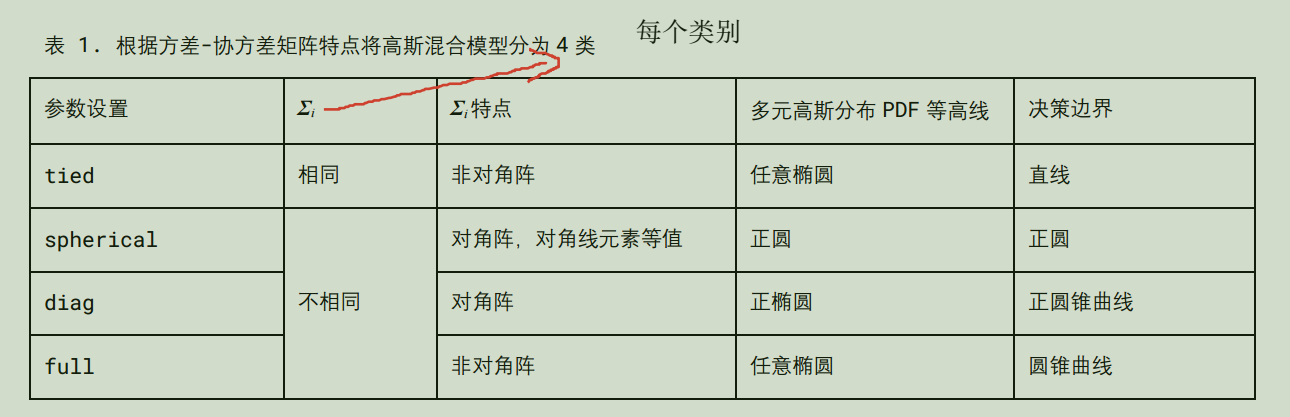

和 K 均值聚类算法一样，高斯混合模型 GMM 也需要指定 K 值；高斯混合模型也是利用迭代求解优
化问题。不同的是，GMM 利用协方差矩阵，可以估算后验概率/成员值。


1.前文提过，GMM 的协方差矩阵
有四种类型，每种类型对应不同假设，获得不同决策边界类型。
K 均值聚类可以看作是高斯混合模型一个特例。

2.如图 6 所示，K 均值聚类对应的 GMM 特点是，各簇
协方差矩阵 Σj相同，Σj为对角阵，并且 Σj主对角线元素相等。


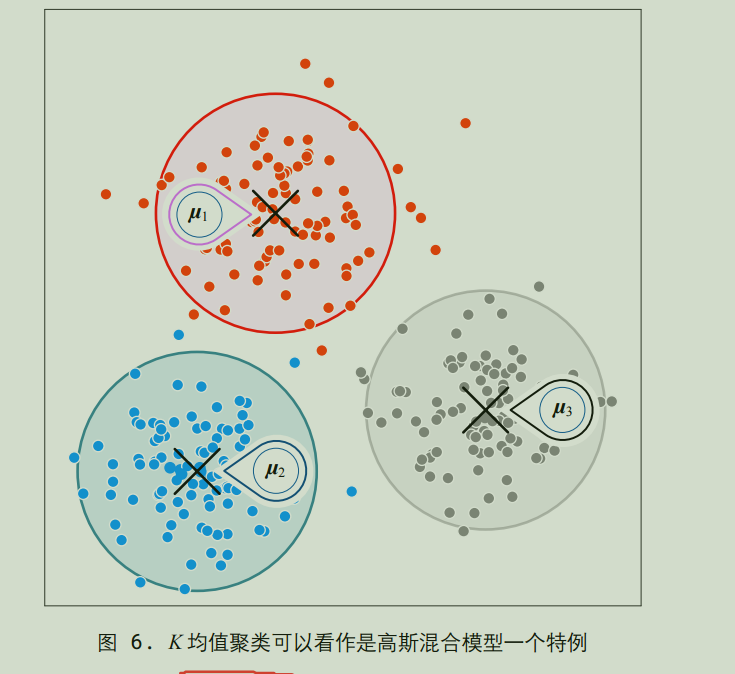

# 图像

##平移tied

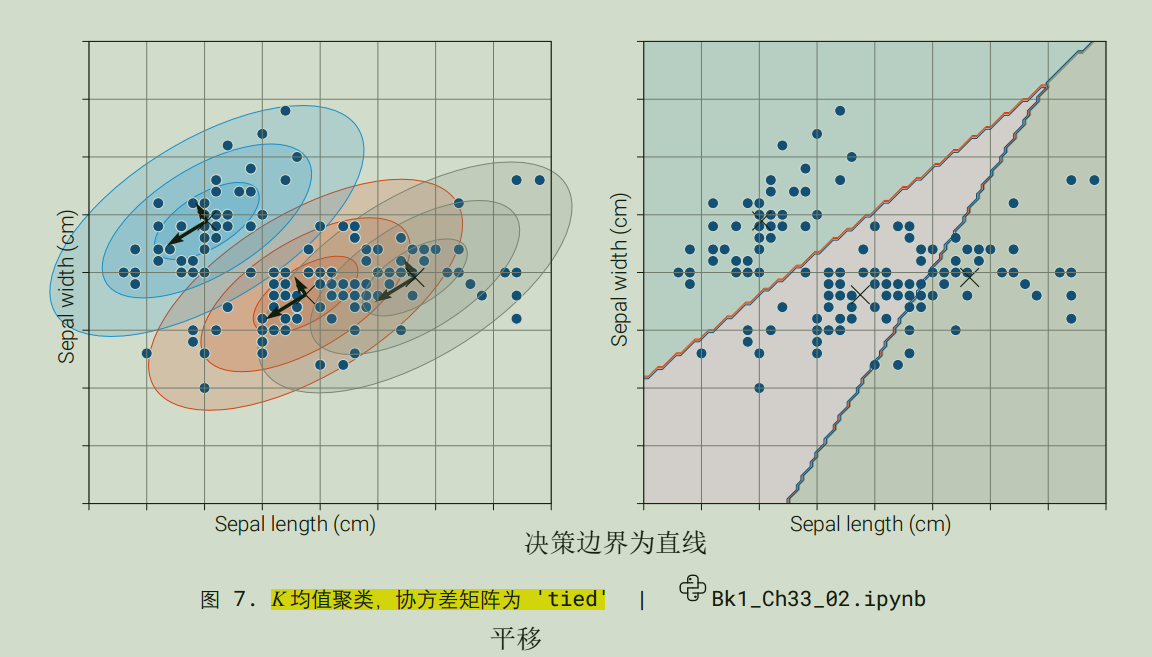

##球面spherical'

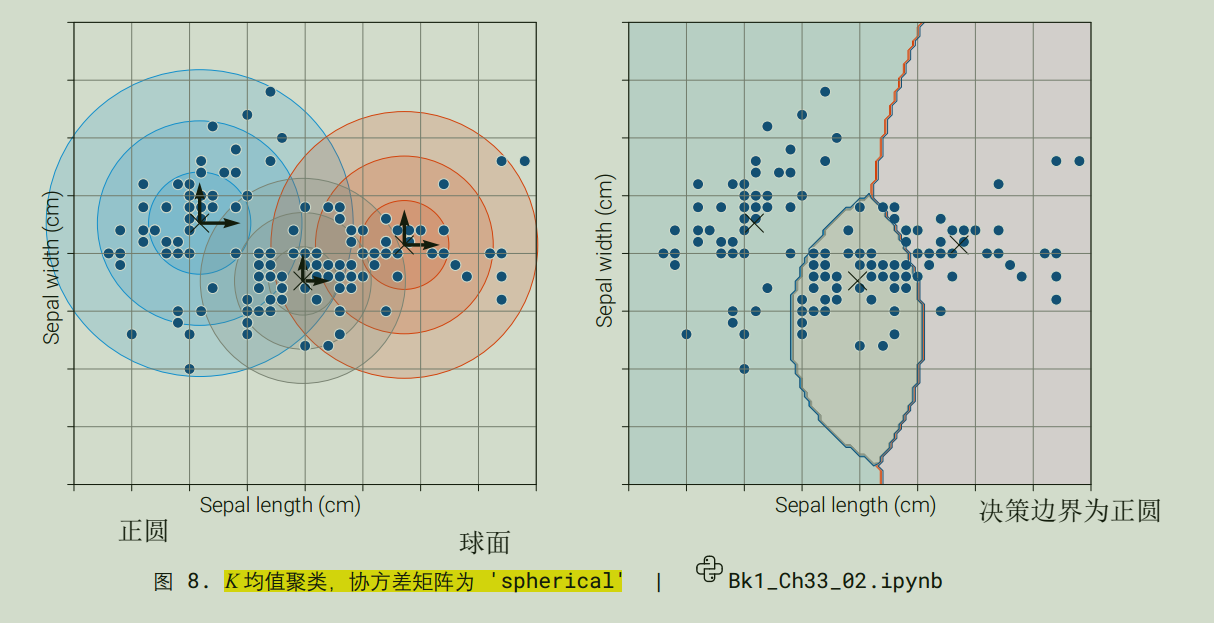

##对角diag

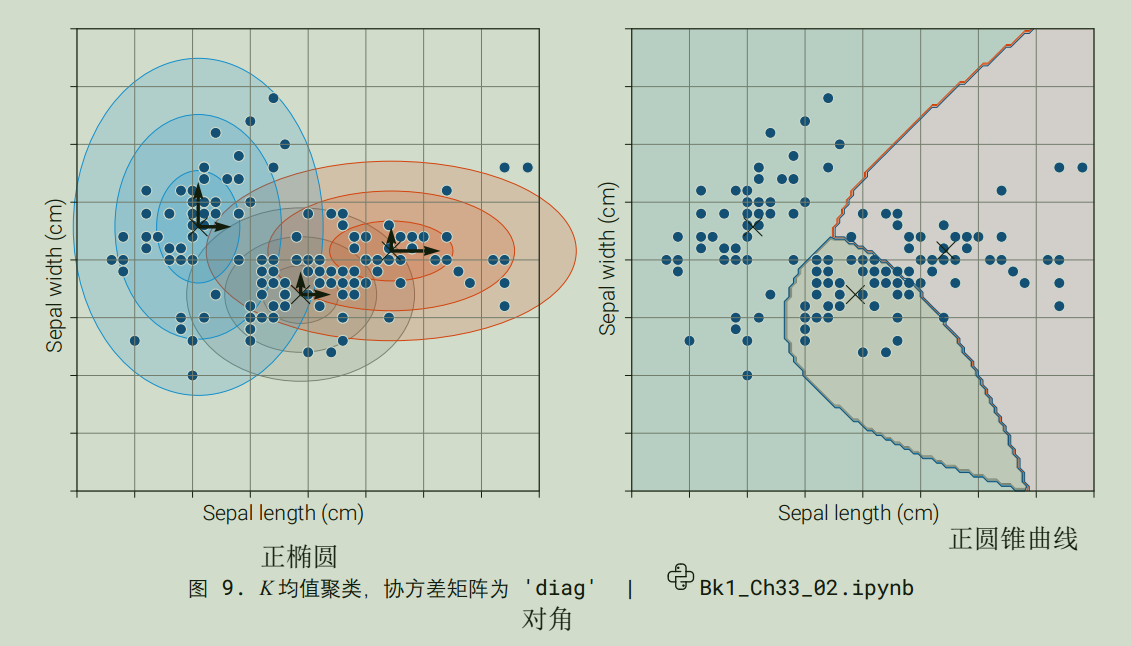

##完全'full'

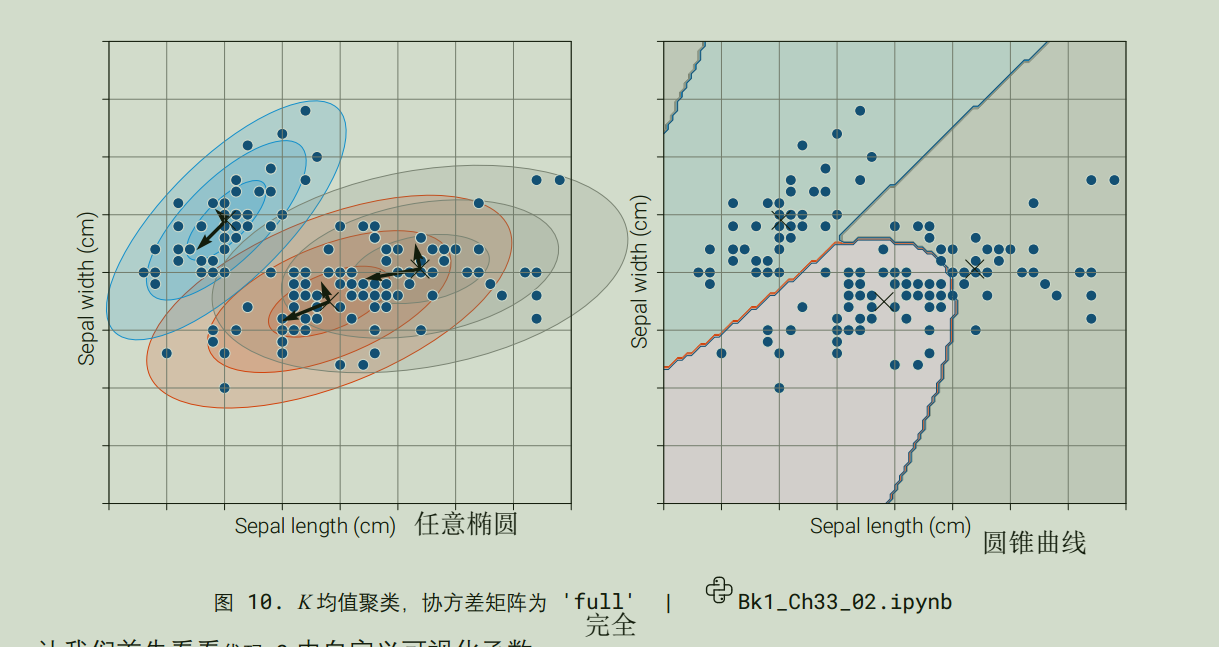

#绘制图像

前文提过，GMM 可以有不同的协方差类型，包括 'full'、'tied'、'diag' 和
'spherical'，它们分别表示完整协方差矩阵、共享协方差矩阵、对角协方差矩阵和球状协方差矩
阵。


这个条件判断语句检查 GMM 对象的协方差类型是否为 'full'。根据技术文档，这种情况下，
协方差矩阵形状为 (n_components, n_features, n_features)，三维 NumPy 数组。
其中，axis = 0 对应的是不同簇。也就是说，如图 10 所示，不同簇协方差矩阵不同，
gmm.covariances_[j] 提取的是不同簇的协方差矩阵，结果为二维 NumPy 数组。

判断 GMM 对象的协方差类型是否为 'tied'。根据技术文档，这种情况下，协方差矩阵形状为
(n_features, n_features)，二维 NumPy 数组。这意味着不同簇的协方差矩阵完全相同，如图 7
**所示。（为对角矩阵；分别对应不同的值）**


也就是说，如图 9 所示，从 GMM 对象的 gmm.covariances_[j] 属性中获取第 j 个分量的协
方差矩阵，结果为一维数组；然后，使用 np.diag() 函数将其转换为对角矩阵形式，结果为二维数
组。



判断 GMM 对象的协方差类型是否为 'spherical'。根据技术文档，这种情况下，协方差矩阵
形状为 (n_components,)，一维 NumPy 数组。
其中，axis = 0 对应不同簇。也就是说，如图 8 所示，将单位矩阵的每个维度上的方差都乘以相
应的协方差值，从而形成一个球状的协方差矩阵 **每一个簇；对应一个对角矩阵**

实际上用奇异值函数 numpy.linalg.svd() 完成的是协方差矩阵的特征值分解。这个矩阵分
解，可以帮我们了解一个旋转椭圆的半长轴、半短轴的长度，以及椭圆的旋转角度。《矩阵力量》将具
体讲解数学工具背后的原理。


In [12]:
from matplotlib.patches import Ellipse #从 matplotlib.patches 导入 Ellipse 类，Ellipse 用来绘制椭圆形状
# 定义可视化函数
def make_ellipses(gmm, ax):

    # 可视化不同簇
    for j in range(0,K):
        # 四种不同的协方差矩阵
        if gmm.covariance_type == 'full':
            covariances = gmm.covariances_[j] # 获取每个簇不同的协方差矩阵
        elif gmm.covariance_type == 'tied':
          # 每个簇的协方差矩阵一致
            covariances = gmm.covariances_
        elif gmm.covariance_type == 'diag':
          # 将一维数组的方差值；转为对角矩阵
            covariances = np.diag(gmm.covariances_[j])
        elif gmm.covariance_type == 'spherical':
          # 对角元素相同；获取特征数量；推断是获取特征以构建单位矩阵
            covariances = np.eye(gmm.means_.shape[1])
            # 如图 8 所示，将单位矩阵的每个维度上的方差都乘以相应的协方差值，从而形成一个球状的协方差矩阵。
            covariances = covariances*gmm.covariances_[j]

        # 用奇异值分解完成特征值分解

        '''
      实际上用奇异值函数 numpy.linalg.svd() 完成的是协方差矩阵的特征值分解。
      这个矩阵分解，可以帮我们了解一个旋转椭圆的半长轴、半短轴的长度，以及椭圆的旋转角度
        '''
        U, S, V_T = np.linalg.svd(covariances)
        # 计算长轴、短轴长度
        major, minor = 2 * np.sqrt(S) #S为方差；标准差
        # 打印长短轴
        print('major: ',major)
        print('minor: ',minor)

        # 计算椭圆长轴旋转角度；y/x
        angle = np.arctan2(U[1,0], U[0,0])
        # 计算角度值
        angle = 180 * angle / np.pi

        # 多元高斯分布中心;获取质心
        ax.plot(gmm.means_[j, 0],gmm.means_[j, 1],
                 color = 'k',marker = 'x',markersize = 10)#marker;标记

        # 绘制半长轴向量
        # 质心的位置到特征向量的第一列；也就是第一个向量；
        ax.quiver(gmm.means_[j,0],gmm.means_[j,1],
                  U[0,0], U[1,0], scale = 5/major)
        # scale: Scales the length of the arrow inversely

        # 绘制半短轴向量
        # 质心的位置到特征向量的第二列；也就是第二个向量；
        ax.quiver(gmm.means_[j,0],gmm.means_[j,1],
                  U[0,1], U[1,1], scale = 5/minor)

        # 绘制椭圆
        #建了一个椭圆对象，指定了椭圆的中心坐标、长轴宽度、短轴宽度、旋转角度、边缘颜色和填充
        #颜色。然后，我们使用 ax.add_patch() 将椭圆添加到图中。
        for scale in np.array([3, 2, 1]):

            ell = Ellipse(gmm.means_[j,:2], # 中心坐标
                          scale*major,# 长轴
                          scale*minor, # 短轴
                          angle=angle,  # 角度
                          color=rgb[j,:], # 获取行数据
                          alpha = 0.18) # 透明度
            ax.add_artist(ell) # 加入

# 绘制

major:  1.0219823858394301
minor:  0.466818039391413
major:  1.0219823858394301
minor:  0.466818039391413
major:  1.0219823858394301
minor:  0.466818039391413
major:  0.7694955541113371
minor:  0.7694955541113371
major:  0.885264756736527
minor:  0.885264756736527
major:  0.5915523699357419
minor:  0.5915523699357419
major:  1.0606908078285848
minor:  0.5178103952840788
major:  0.6658800518924981
minor:  0.5041885115178855
major:  0.9712577493109081
minor:  0.7197363059942701
major:  1.2181714081727162
minor:  0.5650800000974154
major:  0.9111473265826259
minor:  0.3511903237052659
major:  1.1186803073122111
minor:  0.4805918931364427


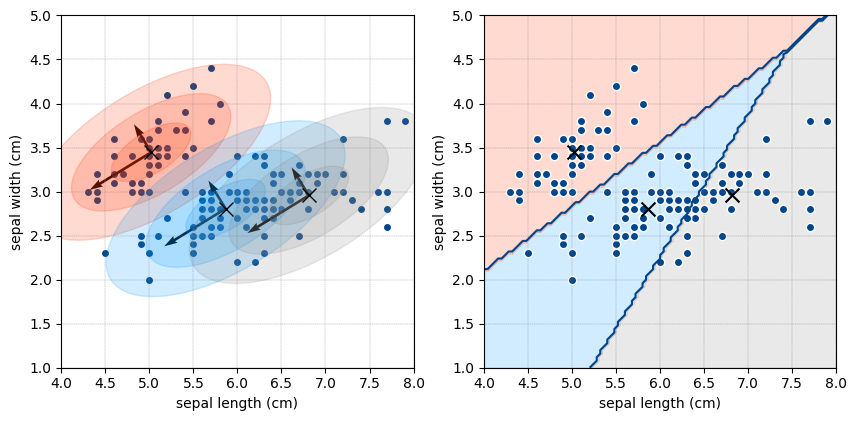

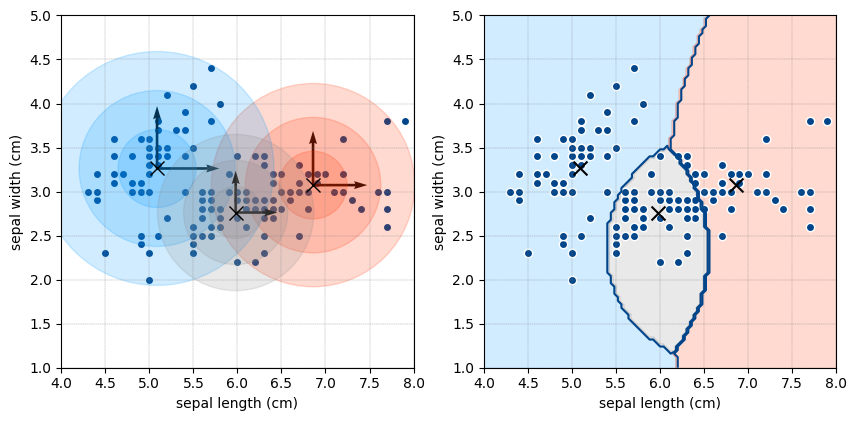

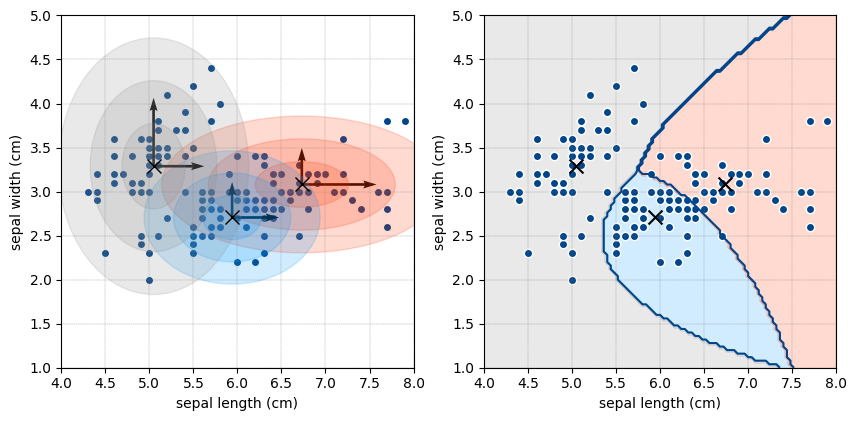

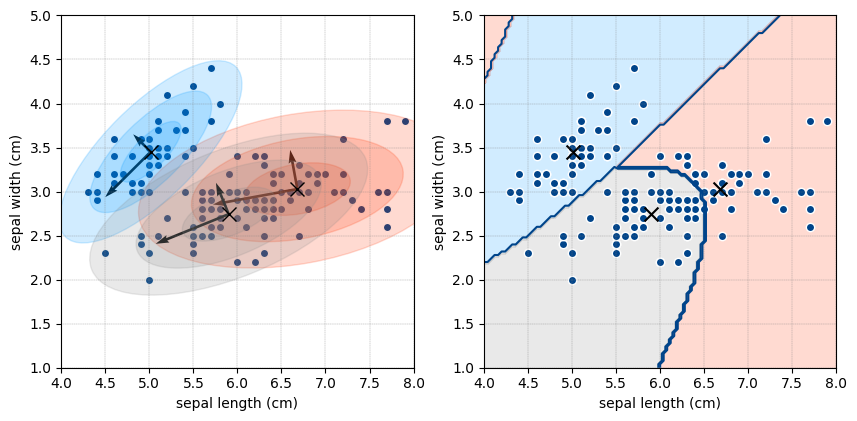

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap #创建离散颜色映射
import numpy as np
from sklearn import datasets
from sklearn.mixture import GaussianMixture # 高斯混合

# 创建色谱
rgb = [[255, 51, 0],
       [0, 153, 255],
       [138,138,138]]
rgb = np.array(rgb)/255. #归一化
cmap_bold = ListedColormap(rgb) #创建离散颜色映射

# 生成网格化数据
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1, xx2 = np.meshgrid(x1_array,x2_array)

# 鸢尾花数据；获取前两列数据
iris = datasets.load_iris(); X = iris.data[:, :2]

K = 3 # 簇数
# 协方差类型
covariance_types = ['tied', 'spherical', 'diag', 'full']

# 遍历协方差类型
for covariance_type in covariance_types:
    # 采用GMM聚类
    gmm = GaussianMixture(n_components=K,
                          covariance_type=covariance_type)
    gmm.fit(X) # 训练数据
    Z = gmm.predict(np.c_[xx1.ravel(), xx2.ravel()]) # 预测数据
    Z = Z.reshape(xx1.shape) # 重置数组形状（101*101）

    # 可视化
    fig = plt.figure(figsize = (10,5))
    ax = fig.add_subplot(1,2,1)
    # 散点图；原始数据
    ax.scatter(x=X[:, 0], y=X[:, 1],
               color=np.array([0, 68, 138])/255.,
               alpha=1.0,
               linewidth = 1, edgecolor=[1,1,1])
    # 绘制椭圆和向量
    make_ellipses(gmm, ax) # 调用函数；绘制椭圆
    ax.set_xlim(4, 8); ax.set_ylim(1, 5) # 范围
    ax.set_xlabel(iris.feature_names[0]) # 标签
    ax.set_ylabel(iris.feature_names[1])
    ax.grid(linestyle='--', linewidth=0.25,  # 网格格式
            color=[0.5,0.5,0.5]) # 灰色
    ax.set_aspect('equal', adjustable='box') # 比例一致

    # 子图2
    ax = fig.add_subplot(1,2,2)
    # 绘制填充等高线
    ax.contourf(xx1, xx2, Z, cmap=cmap_bold, alpha = 0.18)
    # 等高线；三个类别
    ax.contour(xx1, xx2, Z, levels=[0,1,2],
               colors=np.array([0, 68, 138])/255.)
    # 原始数据的散点图
    ax.scatter(x=X[:, 0], y=X[:, 1],
               color=np.array([0, 68, 138])/255.,
               alpha=1.0,
               linewidth = 1, edgecolor=[1,1,1])

    # 获取质心
    centroids = gmm.means_
    # 绘制质心散点图
    ax.scatter(centroids[:, 0], centroids[:, 1],
               marker="x", s=100, linewidths=1.5,
               color="k")
    ax.set_xlim(4, 8); ax.set_ylim(1, 5)
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])
    ax.grid(linestyle='--', linewidth=0.25,
            color=[0.5,0.5,0.5])
    ax.set_aspect('equal', adjustable='box')


##补充

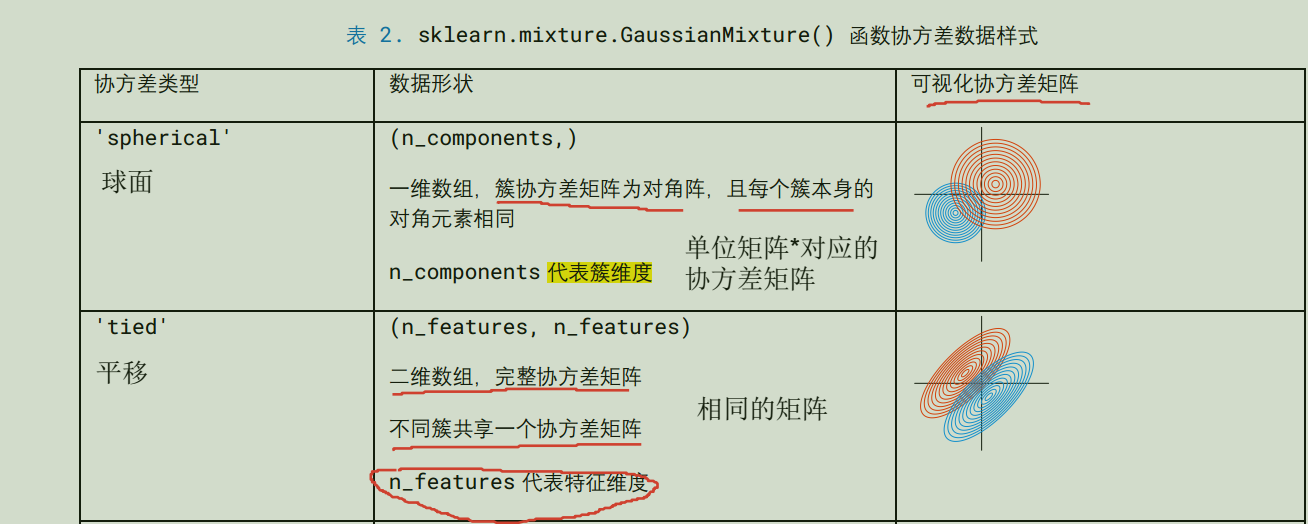

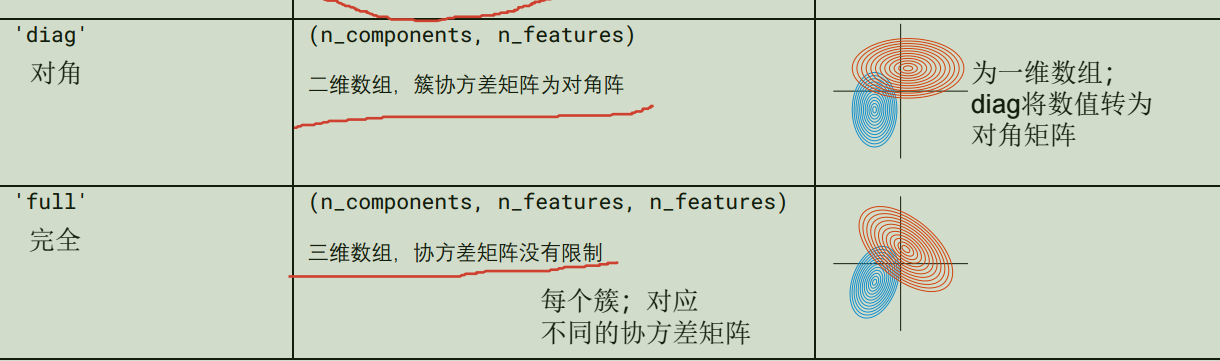

# 步骤拆解

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from sklearn import datasets
from sklearn.mixture import GaussianMixture
# 创建色谱
rgb = [[255, 51, 0],
 [0, 153, 255],
 [138,138,138]]
rgb = np.array(rgb)/255.
cmap_bold = ListedColormap(rgb)
# 生成网格化数据
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1, xx2 = np.meshgrid(x1_array,x2_array)
# 鸢尾花数据
iris = datasets.load_iris(); X = iris.data[:, :2]
K = 3 # 簇数
# 协方差类型
covariance_types = ['tied', 'spherical', 'diag', 'full']

In [15]:
from matplotlib.patches import Ellipse #从 matplotlib.patches 导入 Ellipse 类，Ellipse 用来绘制椭圆形状

major:  1.0228378427340474
minor:  0.46681360710862563
major:  1.0228378427340474
minor:  0.46681360710862563
major:  1.0228378427340474
minor:  0.46681360710862563


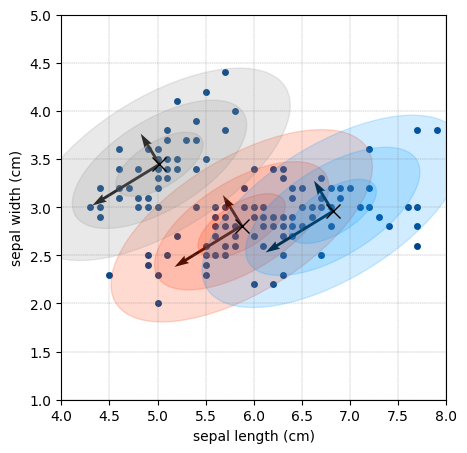

In [18]:
gmm = GaussianMixture(n_components=K,
      covariance_type=covariance_types[0])
gmm.fit(X)
Z = gmm.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)
 # 可视化
fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot()

ax.scatter(x=X[:, 0], y=X[:, 1],
      color=np.array([0, 68, 138])/255.,
      alpha=1.0,
      linewidth = 1, edgecolor=[1,1,1])
 # 绘制椭圆和向量

# 可视化不同簇
for j in range(0,K):
  # 四种不同的协方差矩阵
    if gmm.covariance_type == 'full':
        covariances = gmm.covariances_[j] # 获取每个簇不同的协方差矩阵
    elif gmm.covariance_type == 'tied':
      # 每个簇的协方差矩阵一致
        covariances = gmm.covariances_
    elif gmm.covariance_type == 'diag':
      # 将一维数组的方差值；转为对角矩阵
        covariances = np.diag(gmm.covariances_[j])
    elif gmm.covariance_type == 'spherical':
      # 对角元素相同；获取特征数量；推断是获取特征以构建单位矩阵
        covariances = np.eye(gmm.means_.shape[1])
        # 如图 8 所示，将单位矩阵的每个维度上的方差都乘以相应的协方差值，从而形成一个球状的协方差矩阵。
        covariances = covariances*gmm.covariances_[j]

    # 用奇异值分解完成特征值分解

    '''
    实际上用奇异值函数 numpy.linalg.svd() 完成的是协方差矩阵的特征值分解。
    这个矩阵分解，可以帮我们了解一个旋转椭圆的半长轴、半短轴的长度，以及椭圆的旋转角度
    '''
    U, S, V_T = np.linalg.svd(covariances)
    # 计算长轴、短轴长度
    major, minor = 2 * np.sqrt(S) #S为方差；标准差
    # 打印长短轴
    print('major: ',major)
    print('minor: ',minor)

    # 计算椭圆长轴旋转角度；y/x
    angle = np.arctan2(U[1,0], U[0,0])
    # 计算角度值
    angle = 180 * angle / np.pi

    # 多元高斯分布中心;获取质心
    ax.plot(gmm.means_[j, 0],gmm.means_[j, 1],
            color = 'k',marker = 'x',markersize = 10)#marker;标记

    # 绘制半长轴向量
    # 质心的位置到特征向量的第一列；也就是第一个向量；
    ax.quiver(gmm.means_[j,0],gmm.means_[j,1],
            U[0,0], U[1,0], scale = 5/major)
    # scale: Scales the length of the arrow inversely

    # 绘制半短轴向量
    # 质心的位置到特征向量的第二列；也就是第二个向量；
    ax.quiver(gmm.means_[j,0],gmm.means_[j,1],
            U[0,1], U[1,1], scale = 5/minor)

    # 绘制椭圆
    #建了一个椭圆对象，指定了椭圆的中心坐标、长轴宽度、短轴宽度、旋转角度、边缘颜色和填充
    #颜色。然后，我们使用 ax.add_patch() 将椭圆添加到图中。
    for scale in np.array([3, 2, 1]):

      ell = Ellipse(gmm.means_[j,:2], # 中心坐标
                    scale*major,# 长轴
                    scale*minor, # 短轴
                    angle=angle,  # 角度
                    color=rgb[j,:], # 获取行数据
                    alpha = 0.18) # 透明度
      ax.add_artist(ell) # 加入

ax.set_xlim(4, 8); ax.set_ylim(1, 5)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,
color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')



In [ ]:
##提示

--奇异值分解---
U: [[-0.85264978 -0.52248287]
 [-0.52248287  0.85264978]]
S: [0.261112   0.05447977]
V_T: [[-0.85264978 -0.52248287]
 [-0.52248287  0.85264978]]
major:  1.0219823858394788
minor:  0.4668180393913974
angle: -2.5918323458998875
angle: -148.50105462555487
------获取质心------
gmm.means_: [[6.81029145 2.95576606]
 [5.86590845 2.80594965]
 [5.02053944 3.44607726]]


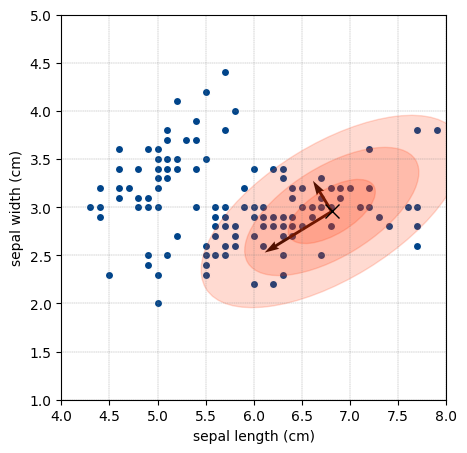

In [24]:
gmm = GaussianMixture(n_components=K,
      covariance_type=covariance_types[0])
gmm.fit(X)
Z = gmm.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)
 # 可视化
fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot()

ax.scatter(x=X[:, 0], y=X[:, 1],
      color=np.array([0, 68, 138])/255.,
      alpha=1.0,
      linewidth = 1, edgecolor=[1,1,1])
 # 绘制椭圆和向量

# 可视化不同簇
# 四种不同的协方差矩阵

j = 0
if gmm.covariance_type == 'full':
    covariances = gmm.covariances_[j] # 获取每个簇不同的协方差矩阵
elif gmm.covariance_type == 'tied':
  # 每个簇的协方差矩阵一致
    covariances = gmm.covariances_
elif gmm.covariance_type == 'diag':
  # 将一维数组的方差值；转为对角矩阵
    covariances = np.diag(gmm.covariances_[j])
elif gmm.covariance_type == 'spherical':
  # 对角元素相同；获取特征数量；推断是获取特征以构建单位矩阵
    covariances = np.eye(gmm.means_.shape[1])
    # 如图 8 所示，将单位矩阵的每个维度上的方差都乘以相应的协方差值，从而形成一个球状的协方差矩阵。
    covariances = covariances*gmm.covariances_[j]

# 用奇异值分解完成特征值分解

'''
实际上用奇异值函数 numpy.linalg.svd() 完成的是协方差矩阵的特征值分解。
这个矩阵分解，可以帮我们了解一个旋转椭圆的半长轴、半短轴的长度，以及椭圆的旋转角度
'''
U, S, V_T = np.linalg.svd(covariances)

print("--奇异值分解---")
print(f"U: {U}")
print(f"S: {S}")
print(f"V_T: {V_T}")
# 计算长轴、短轴长度
major, minor = 2 * np.sqrt(S) #S为方差；标准差
# 打印长短轴
print('major: ',major)
print('minor: ',minor)

# 计算椭圆长轴旋转角度；y/x
angle = np.arctan2(U[1,0], U[0,0])
print(f"angle: {angle}")
# 计算角度值
angle = 180 * angle / np.pi
print(f"angle: {angle}")
print("------获取质心------")
print(f"gmm.means_: {gmm.means_}")
# 多元高斯分布中心;获取质心
ax.plot(gmm.means_[j, 0],gmm.means_[j, 1],
        color = 'k',marker = 'x',markersize = 10)#marker;标记

# 绘制半长轴向量
# 质心的位置到特征向量的第一列；也就是第一个向量；
ax.quiver(gmm.means_[j,0],gmm.means_[j,1],
        U[0,0], U[1,0], scale = 5/major)
# scale: Scales the length of the arrow inversely

# 绘制半短轴向量
# 质心的位置到特征向量的第二列；也就是第二个向量；
ax.quiver(gmm.means_[j,0],gmm.means_[j,1],
        U[0,1], U[1,1], scale = 5/minor)

# 绘制椭圆
#建了一个椭圆对象，指定了椭圆的中心坐标、长轴宽度、短轴宽度、旋转角度、边缘颜色和填充
#颜色。然后，我们使用 ax.add_patch() 将椭圆添加到图中。
for scale in np.array([3, 2, 1]):

  ell = Ellipse(gmm.means_[j,:2], # 中心坐标
                scale*major,# 长轴
                scale*minor, # 短轴
                angle=angle,  # 角度
                color=rgb[j,:], # 获取行数据
                alpha = 0.18) # 透明度
  ax.add_artist(ell) # 加入

ax.set_xlim(4, 8); ax.set_ylim(1, 5)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,
color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')



# **看数据好像是根据质心的位置作为参考系**

--奇异值分解---
U: [[-0.85274465 -0.52232801]
 [-0.52232801  0.85274465]]
S: [0.26154931 0.05447874]
V_T: [[-0.85274465 -0.52232801]
 [-0.52232801  0.85274465]]
major:  1.0228378427340212
minor:  0.4668136071086242
angle: -2.59201395309818
angle: -148.51145995154621
------获取质心------
gmm.means_: [[5.8742648  2.80750129]
 [5.02046489 3.44589039]
 [6.82070679 2.9570364 ]]


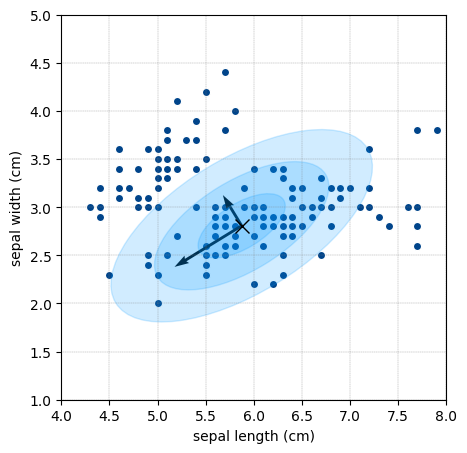

In [31]:
gmm = GaussianMixture(n_components=K,
      covariance_type=covariance_types[0])
gmm.fit(X)
Z = gmm.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)
 # 可视化
fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot()

ax.scatter(x=X[:, 0], y=X[:, 1],
      color=np.array([0, 68, 138])/255.,
      alpha=1.0,
      linewidth = 1, edgecolor=[1,1,1])
 # 绘制椭圆和向量

# 可视化不同簇
# 四种不同的协方差矩阵

j = 1
if gmm.covariance_type == 'full':
    covariances = gmm.covariances_[j] # 获取每个簇不同的协方差矩阵
elif gmm.covariance_type == 'tied':
  # 每个簇的协方差矩阵一致
    covariances = gmm.covariances_
elif gmm.covariance_type == 'diag':
  # 将一维数组的方差值；转为对角矩阵
    covariances = np.diag(gmm.covariances_[j])
elif gmm.covariance_type == 'spherical':
  # 对角元素相同；获取特征数量；推断是获取特征以构建单位矩阵
    covariances = np.eye(gmm.means_.shape[1])
    # 如图 8 所示，将单位矩阵的每个维度上的方差都乘以相应的协方差值，从而形成一个球状的协方差矩阵。
    covariances = covariances*gmm.covariances_[j]

# 用奇异值分解完成特征值分解

'''
实际上用奇异值函数 numpy.linalg.svd() 完成的是协方差矩阵的特征值分解。
这个矩阵分解，可以帮我们了解一个旋转椭圆的半长轴、半短轴的长度，以及椭圆的旋转角度
'''
U, S, V_T = np.linalg.svd(covariances)

print("--奇异值分解---")
print(f"U: {U}")
print(f"S: {S}")
print(f"V_T: {V_T}")
# 计算长轴、短轴长度
major, minor = 2 * np.sqrt(S) #S为方差；标准差
# 打印长短轴
print('major: ',major)
print('minor: ',minor)

# 计算椭圆长轴旋转角度；y/x
angle = np.arctan2(U[1,0], U[0,0])
print(f"angle: {angle}")
# 计算角度值
angle = 180 * angle / np.pi
print(f"angle: {angle}")
print("------获取质心------")
print(f"gmm.means_: {gmm.means_}")
# 多元高斯分布中心;获取质心
ax.plot(gmm.means_[0, 0],gmm.means_[0, 1],
        color = 'k',marker = 'x',markersize = 10)#marker;标记

# 绘制半长轴向量
# 质心的位置到特征向量的第一列；也就是第一个向量；
ax.quiver(gmm.means_[0,0],gmm.means_[0,1],
        U[0,0], U[1,0], scale = 5/major)
# scale: Scales the length of the arrow inversely

# 绘制半短轴向量
# 质心的位置到特征向量的第二列；也就是第二个向量；
ax.quiver(gmm.means_[0,0],gmm.means_[0,1],
        U[0,1], U[1,1], scale = 5/minor)

# 绘制椭圆
#建了一个椭圆对象，指定了椭圆的中心坐标、长轴宽度、短轴宽度、旋转角度、边缘颜色和填充
#颜色。然后，我们使用 ax.add_patch() 将椭圆添加到图中。
for scale in np.array([3, 2, 1]):

  ell = Ellipse(gmm.means_[0,:2], # 中心坐标
                scale*major,# 长轴
                scale*minor, # 短轴
                angle=angle,  # 角度
                color=rgb[j,:], # 获取行数据
                alpha = 0.18) # 透明度
  ax.add_artist(ell) # 加入

ax.set_xlim(4, 8); ax.set_ylim(1, 5)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,
color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')



--奇异值分解---
U: [[-0.85264978 -0.52248287]
 [-0.52248287  0.85264978]]
S: [0.261112   0.05447977]
V_T: [[-0.85264978 -0.52248287]
 [-0.52248287  0.85264978]]
major:  1.0219823858394883
minor:  0.4668180393914089
angle: -2.5918323458999306
angle: -148.50105462555734
------获取质心------
gmm.means_: [[5.86590845 2.80594965]
 [6.81029145 2.95576606]
 [5.02053944 3.44607726]]


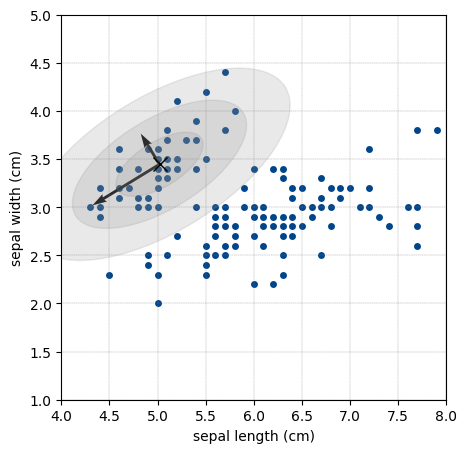

In [27]:
gmm = GaussianMixture(n_components=K,
      covariance_type=covariance_types[0])
gmm.fit(X)
Z = gmm.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)
 # 可视化
fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot()

ax.scatter(x=X[:, 0], y=X[:, 1],
      color=np.array([0, 68, 138])/255.,
      alpha=1.0,
      linewidth = 1, edgecolor=[1,1,1])
 # 绘制椭圆和向量

# 可视化不同簇
# 四种不同的协方差矩阵

j = 2
if gmm.covariance_type == 'full':
    covariances = gmm.covariances_[j] # 获取每个簇不同的协方差矩阵
elif gmm.covariance_type == 'tied':
  # 每个簇的协方差矩阵一致
    covariances = gmm.covariances_
elif gmm.covariance_type == 'diag':
  # 将一维数组的方差值；转为对角矩阵
    covariances = np.diag(gmm.covariances_[j])
elif gmm.covariance_type == 'spherical':
  # 对角元素相同；获取特征数量；推断是获取特征以构建单位矩阵
    covariances = np.eye(gmm.means_.shape[1])
    # 如图 8 所示，将单位矩阵的每个维度上的方差都乘以相应的协方差值，从而形成一个球状的协方差矩阵。
    covariances = covariances*gmm.covariances_[j]

# 用奇异值分解完成特征值分解

'''
实际上用奇异值函数 numpy.linalg.svd() 完成的是协方差矩阵的特征值分解。
这个矩阵分解，可以帮我们了解一个旋转椭圆的半长轴、半短轴的长度，以及椭圆的旋转角度
'''
U, S, V_T = np.linalg.svd(covariances)

print("--奇异值分解---")
print(f"U: {U}")
print(f"S: {S}")
print(f"V_T: {V_T}")
# 计算长轴、短轴长度
major, minor = 2 * np.sqrt(S) #S为方差；标准差
# 打印长短轴
print('major: ',major)
print('minor: ',minor)

# 计算椭圆长轴旋转角度；y/x
angle = np.arctan2(U[1,0], U[0,0])
print(f"angle: {angle}")
# 计算角度值
angle = 180 * angle / np.pi
print(f"angle: {angle}")
print("------获取质心------")
print(f"gmm.means_: {gmm.means_}")
# 多元高斯分布中心;获取质心
ax.plot(gmm.means_[j, 0],gmm.means_[j, 1],
        color = 'k',marker = 'x',markersize = 10)#marker;标记

# 绘制半长轴向量
# 质心的位置到特征向量的第一列；也就是第一个向量；
ax.quiver(gmm.means_[j,0],gmm.means_[j,1],
        U[0,0], U[1,0], scale = 5/major)
# scale: Scales the length of the arrow inversely

# 绘制半短轴向量
# 质心的位置到特征向量的第二列；也就是第二个向量；
ax.quiver(gmm.means_[j,0],gmm.means_[j,1],
        U[0,1], U[1,1], scale = 5/minor)

# 绘制椭圆
#建了一个椭圆对象，指定了椭圆的中心坐标、长轴宽度、短轴宽度、旋转角度、边缘颜色和填充
#颜色。然后，我们使用 ax.add_patch() 将椭圆添加到图中。
for scale in np.array([3, 2, 1]):

  ell = Ellipse(gmm.means_[j,:2], # 中心坐标
                scale*major,# 长轴
                scale*minor, # 短轴
                angle=angle,  # 角度
                color=rgb[j,:], # 获取行数据
                alpha = 0.18) # 透明度
  ax.add_artist(ell) # 加入

ax.set_xlim(4, 8); ax.set_ylim(1, 5)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,
color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')

